El objetivo: Identificar qué factores (duración del video, hora de publicación, palabras clave en el título) correlacionan con un mayor número de visualizaciones o interacción.

Dataset: Puedes usar el "YouTube Trending Video Dataset" de Kaggle.

Acciones en Python:

* Limpieza de fechas y formatos de tiempo.

* Análisis de sentimientos básico en los títulos usando TextBlob o VADER.

* Visualización de la distribución de categorías más populares.

## Descargar datos al notebook

In [2]:
from pathlib import Path
import zipfile

#Checamos la carpeta o la creamos
DATA_DIR = Path("data/youtube")
ZIP_PATH = DATA_DIR/"youtube-new.zip"

DATA_DIR.mkdir(parents=True,exist_ok=True) #se crea directorio con sus superdirectorios necesarios

if not ZIP_PATH.exists():
    #Si no existe, descargamos y almacenamos en la ruta
    !kaggle datasets download -d datasnaek/youtube-new -p {DATA_DIR}

with zipfile.ZipFile(ZIP_PATH,'r') as zip_ref:
    zip_ref.extractall(DATA_DIR) #Extraemos en la ruta

# Opcional: eliminar zip
# if ZIP_PATH.exists():
#     ZIP_PATH.unlink()

print("Dataset descargado y descomprimido")

Dataset descargado y descomprimido


In [3]:
import pandas as pd

df = pd.read_csv('./data/youtube/Usvideos.csv') #Leemos el archivo de uno de los paises del dataset (se crea un objeto de tipo pandas.dataframe)
df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...


# Vemos un resumen del archivo 

In [4]:
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.\n")
df.info()

El dataset tiene 40949 filas y 16 columnas.

<class 'pandas.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   video_id                40949 non-null  str  
 1   trending_date           40949 non-null  str  
 2   title                   40949 non-null  str  
 3   channel_title           40949 non-null  str  
 4   category_id             40949 non-null  int64
 5   publish_time            40949 non-null  str  
 6   tags                    40949 non-null  str  
 7   views                   40949 non-null  int64
 8   likes                   40949 non-null  int64
 9   dislikes                40949 non-null  int64
 10  comment_count           40949 non-null  int64
 11  thumbnail_link          40949 non-null  str  
 12  comments_disabled       40949 non-null  bool 
 13  ratings_disabled        40949 non-null  bool 
 14  video_error_or_removed  40949 non-nu

In [5]:
#Parametro de interes
df['publish_time']

0        2017-11-13T17:13:01.000Z
1        2017-11-13T07:30:00.000Z
2        2017-11-12T19:05:24.000Z
3        2017-11-13T11:00:04.000Z
4        2017-11-12T18:01:41.000Z
                   ...           
40944    2018-05-18T13:00:04.000Z
40945    2018-05-18T01:00:06.000Z
40946    2018-05-18T17:34:22.000Z
40947    2018-05-17T17:00:04.000Z
40948    2018-05-17T17:09:38.000Z
Name: publish_time, Length: 40949, dtype: str

## Limpieza y preparación  de datos

In [6]:
#Convertimos los valores a formato datetime
df['publish_time'] = pd.to_datetime(df['publish_time'])
df['publish_time']

0       2017-11-13 17:13:01+00:00
1       2017-11-13 07:30:00+00:00
2       2017-11-12 19:05:24+00:00
3       2017-11-13 11:00:04+00:00
4       2017-11-12 18:01:41+00:00
                   ...           
40944   2018-05-18 13:00:04+00:00
40945   2018-05-18 01:00:06+00:00
40946   2018-05-18 17:34:22+00:00
40947   2018-05-17 17:00:04+00:00
40948   2018-05-17 17:09:38+00:00
Name: publish_time, Length: 40949, dtype: datetime64[us, UTC]

In [7]:
#Creamos nuevas columnas con parametros de interes para un futuro analisis
df['publish_hour'] = df['publish_time'].dt.hour #dt.hour es una propiedad, no un metodo
df['publish_day'] = df['publish_time'].dt.day_name()
df['publish_month']= df['publish_time'].dt.month_name()

df[['title','publish_time','publish_day','publish_month']].head() #Mostramos estas columnas para ver el antes y despues de su manipulación

,title,publish_time,publish_day,publish_month
0,WE WANT TO TALK ABOUT OUR MARRIAGE,2017-11-13 17:13:01+00:00,Monday,November
1,The Trump Presidency: Last Week Tonight with J...,2017-11-13 07:30:00+00:00,Monday,November
2,"Racist Superman | Rudy Mancuso, King Bach & Le...",2017-11-12 19:05:24+00:00,Sunday,November
3,Nickelback Lyrics: Real or Fake?,2017-11-13 11:00:04+00:00,Monday,November
4,I Dare You: GOING BALD!?,2017-11-12 18:01:41+00:00,Sunday,November


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   video_id                40949 non-null  str                
 1   trending_date           40949 non-null  str                
 2   title                   40949 non-null  str                
 3   channel_title           40949 non-null  str                
 4   category_id             40949 non-null  int64              
 5   publish_time            40949 non-null  datetime64[us, UTC]
 6   tags                    40949 non-null  str                
 7   views                   40949 non-null  int64              
 8   likes                   40949 non-null  int64              
 9   dislikes                40949 non-null  int64              
 10  comment_count           40949 non-null  int64              
 11  thumbnail_link          40949 non-null  str         

## Traducir las Categorías

El dataset tiene una columna llamada category_id, pero no nos dice qué significa cada número (ej. el 10 es "Music"). Tratando el csv de Usvideos, necesitammos usar un archivo llamado `US_category_id.json`. Para realizar el mapeado correcto.

In [9]:
import json

with open(r'.\data\youtube\US_category_id.json','r') as f:
    categories_data = json.load(f)

categories_data


{'kind': 'youtube#videoCategoryListResponse',
 'etag': '"m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJvJAAShlR6hM"',
 'items': [{'kind': 'youtube#videoCategory',
   'etag': '"m2yskBQFythfE4irbTIeOgYYfBU/Xy1mB4_yLrHy_BmKmPBggty2mZQ"',
   'id': '1',
   'snippet': {'channelId': 'UCBR8-60-B28hp2BmDPdntcQ',
    'title': 'Film & Animation',
    'assignable': True}},
  {'kind': 'youtube#videoCategory',
   'etag': '"m2yskBQFythfE4irbTIeOgYYfBU/UZ1oLIIz2dxIhO45ZTFR3a3NyTA"',
   'id': '2',
   'snippet': {'channelId': 'UCBR8-60-B28hp2BmDPdntcQ',
    'title': 'Autos & Vehicles',
    'assignable': True}},
  {'kind': 'youtube#videoCategory',
   'etag': '"m2yskBQFythfE4irbTIeOgYYfBU/nqRIq97-xe5XRZTxbknKFVe5Lmg"',
   'id': '10',
   'snippet': {'channelId': 'UCBR8-60-B28hp2BmDPdntcQ',
    'title': 'Music',
    'assignable': True}},
  {'kind': 'youtube#videoCategory',
   'etag': '"m2yskBQFythfE4irbTIeOgYYfBU/HwXKamM1Q20q9BN-oBJavSGkfDI"',
   'id': '15',
   'snippet': {'channelId': 'UCBR8-60-B28hp2BmDPdnt

In [10]:
#Mapeamos el id a un titulo
category_map = {item['id']: item['snippet']['title'] for item in categories_data['items']}
#{'1': 'Film & Animation', '2': 'Autos & Vehicles', '10': 'Music' ...}


#El json guarda los IDs como strings, el dataframe que tenemos lo hace como int. Por lo cual asociamos
df['category_id'] = df['category_id'].astype(str) #Tratamos estos valores como str por el archivo json
df['category_name'] = df['category_id'].map(category_map) #Si NO lo encuentra: Pone un valor nulo (NaN), indicando que no hay traducción para ese ID.


# Ejemplo para entender el mapeo realizado en la linea anterior

In [11]:
#Para entender el mapeo con claridad
# Nuestra columna original
ids = pd.Series(['1', '10', '1', '22'])
print(ids,"\n","--"*20)
# Nuestro "traductor" (diccionario)
traductor = {
    '1': 'Cine',
    '10': 'Música',
    '22': 'Videojuegos'
}

#El mapeo occure aquí
nombres = ids.map(traductor)
nombres

0     1
1    10
2     1
3    22
dtype: str 
 ----------------------------------------


0           Cine
1         Música
2           Cine
3    Videojuegos
dtype: str

# Valores nulos

Es común que un buen video dure varios días en tendencia. Por lo que para un analisis general de "los videos que fueron tendencia", deseariamos eliminar duplicados basados en la el valor de la comunda `video_id`

In [12]:
#Primero vemos cuantos valores nulos hay en nuuestro dataframe por columna
print(df.isnull().sum())
print("--"*20)

#Eliminamos filas duplicadas manteniendo solo su ultima versión ("Aquella con más vistas")
df.sort_values('views',ascending=False).drop_duplicates('video_id',keep='first')

print(f"Registros unicos tras limpieza de duplicados:{df.shape[0]}")


video_id                    0
trending_date               0
title                       0
channel_title               0
category_id                 0
publish_time                0
tags                        0
views                       0
likes                       0
dislikes                    0
comment_count               0
thumbnail_link              0
comments_disabled           0
ratings_disabled            0
video_error_or_removed      0
description               570
publish_hour                0
publish_day                 0
publish_month               0
category_name               0
dtype: int64


----------------------------------------
Registros unicos tras limpieza de duplicados:40949


# Primer analisis
### Qué categorias dominan tendensias?

C:\Users\Pacocris2701\AppData\Local\Temp\ipykernel_33760\989896796.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data= df, y= 'category_name', order= df['category_name'].value_counts().index, palette='viridis')


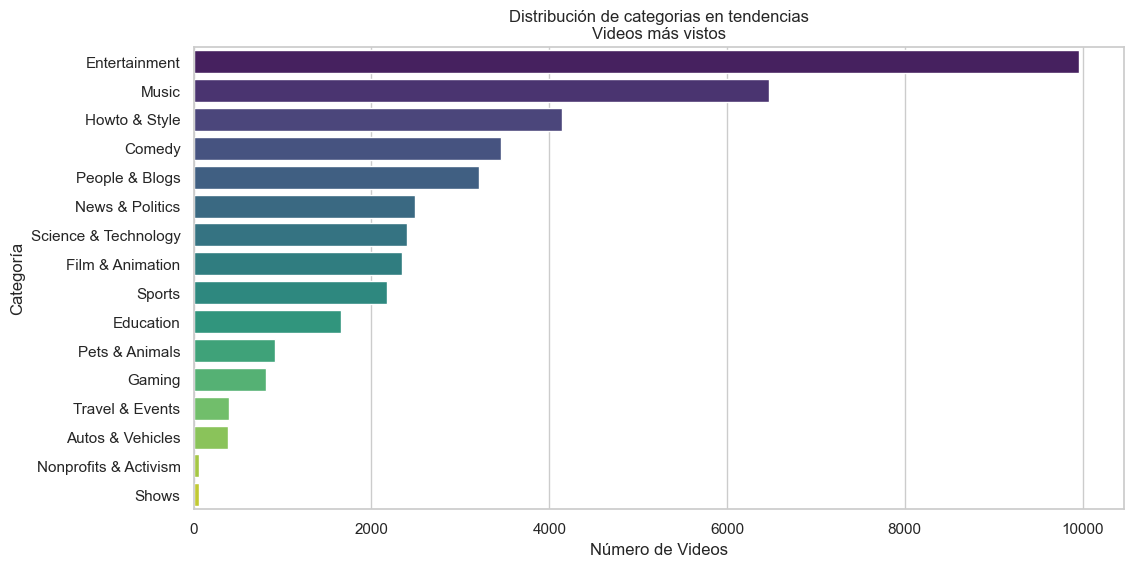

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid") #Maquillaje

plt.figure(figsize=(12,6))
sns.countplot(data= df, y= 'category_name', order= df['category_name'].value_counts().index, palette='viridis')
plt.title('Distribución de categorias en tendencias\nVideos más vistos')
plt.xlabel('Número de Videos')
plt.ylabel('Categoría')
plt.show()




# ¿A qué hora del día es más frecuente que se publiquen los videos que terminan siendo tendencia?

C:\Users\Pacocris2701\AppData\Local\Temp\ipykernel_33760\1276658826.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x='publish_hour',y='views',palette= 'flare',estimator=np.mean)


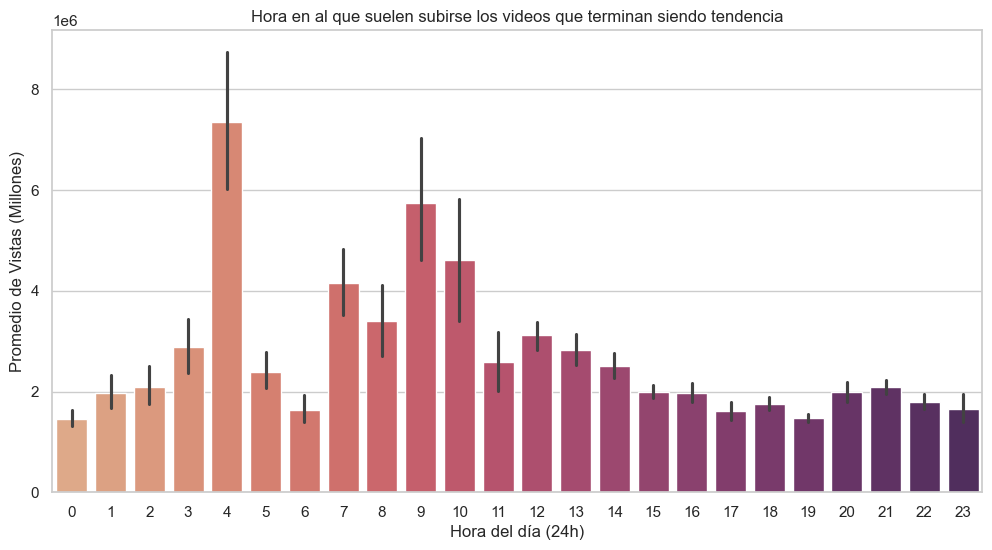

In [35]:
plt.figure(figsize=(12,6))
sns.barplot(data=df,x='publish_hour',y='views',palette= 'flare',estimator=np.mean)
plt.title('Hora en al que suelen subirse los videos que terminan siendo tendencia')
plt.xlabel('Hora del día (24h)')
plt.ylabel('Promedio de Vistas (Millones)')
plt.show()

# Tasa de interacción (Engagement Rate)
Calcularemos qué porcentaje de personas que vieron el video le dieron "Like"

C:\Users\Pacocris2701\AppData\Local\Temp\ipykernel_33760\603140754.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= df,y='category_name',x='Like_rate',palette= 'magma', estimator= np.mean)


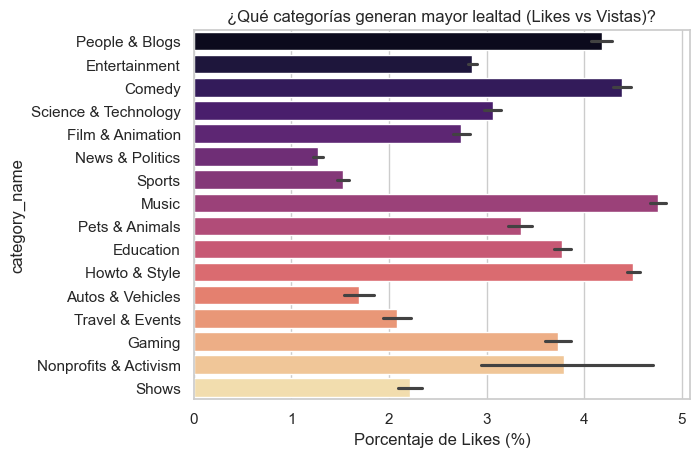

In [ ]:
df['Like_rate'] = (df['likes'] / df['views']) * 100 #Que tantos likes tenemos por 100 visitas
#Analisamos la categoria con un publico más 'activo'
plt.Figure(figsize=(12,6))
sns.barplot(data= df,y='category_name',x='Like_rate',palette= 'magma', estimator= np.mean)
plt.title('¿Qué categorías generan mayor lealtad (Likes vs Vistas)?')
plt.xlabel('Porcentaje de Likes (%)')
plt.show()



# Matriz de correlación
¿Si un video tiene muchos likes, necesariamente tiene muchos comentarios? ¿Los "dislikes" frenan las visitas?

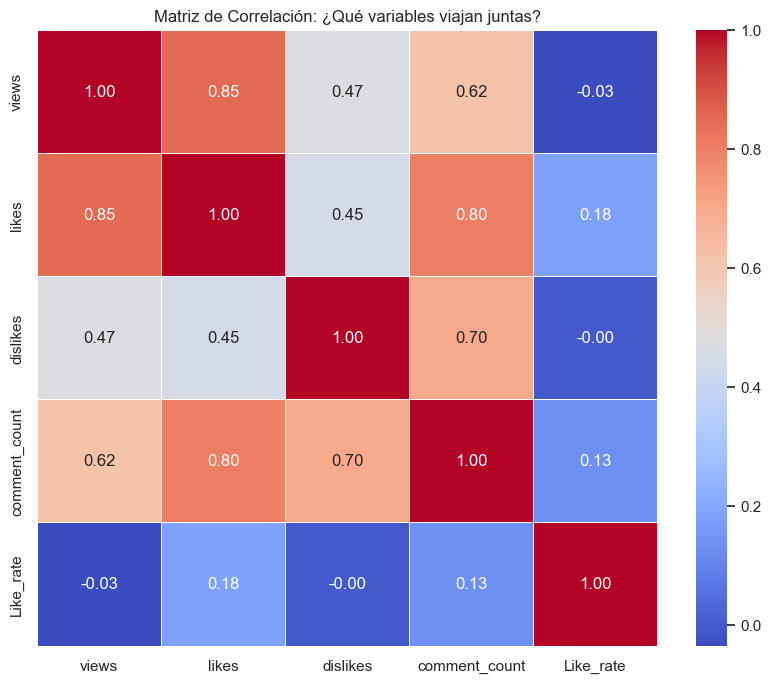

In [ ]:
cols_interest = ['views', 'likes', 'dislikes', 'comment_count', 'Like_rate'] #Columnas de interes
correlation_matrix = df[cols_interest].corr() #Creamos la correlación entre cada una de las columnas de interes
'''
1: correlación fuerte, si uno sube, el otro debe hacerlo tambien
-1: correlación negativa, Si una sube, la otra baja.
0: No correlación
'''

plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5)
plt.title('Matriz de Correlación: ¿Qué variables viajan juntas?')
plt.show()

C:\Users\Pacocris2701\AppData\Local\Temp\ipykernel_33760\3577361498.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='publish_hour', y='views', palette='viridis')


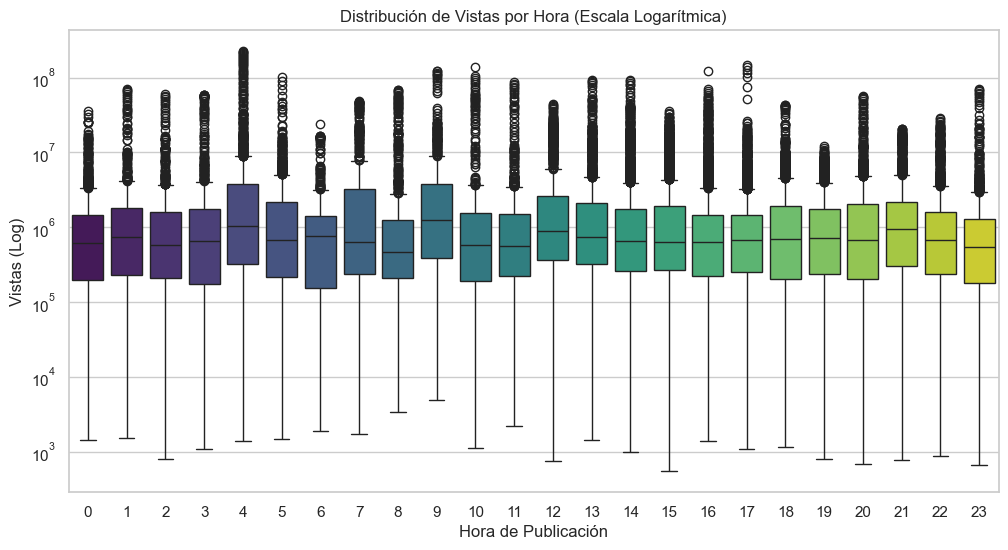

In [41]:
plt.figure(figsize=(12,6))
# Usamos escala logarítmica en Y porque las vistas varían desde miles hasta millones
sns.boxplot(data=df, x='publish_hour', y='views', palette='viridis')
plt.yscale('log') 
plt.title('Distribución de Vistas por Hora (Escala Logarítmica)')
plt.xlabel('Hora de Publicación')
plt.ylabel('Vistas (Log)')
plt.show()